# PCA — Dimensionality Reduction (MNIST 0 / 1 / 2)

Each MNIST image lives in a **784-dimensional** pixel space, but the digits `0`, `1`, `2` occupy a much thinner slice of it. This notebook uses **Principal Component Analysis** to find that slice: an orthogonal basis ordered by how much variance each axis explains.

We reuse the shared loader ([`utils/mnist_data.py`](../utils/mnist_data.py)) and the helpers in [`utils/pca/dim_reduction.py`](../utils/pca/dim_reduction.py) — PCA implemented from scratch (mean-centering, a covariance matrix, and an eigendecomposition, no `sklearn.decomposition.PCA`) so every step stays visible — then:

1. plot the scree / cumulative explained-variance curve,
2. report how many components reach **90%** and **95%** of the variance, and
3. scatter the first 2 (and 3) principal components, colored by digit.

In [1]:
import sys
from pathlib import Path

# Make src/ importable whether the kernel starts at the repo root, in src/, or in src/pca/.
for cand in (Path.cwd(), *Path.cwd().parents):
    if (cand / "utils" / "mnist_data.py").exists():
        sys.path.insert(0, str(cand)); break
    if (cand / "src" / "utils" / "mnist_data.py").exists():
        sys.path.insert(0, str(cand / "src")); break

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from utils.mnist_data import load_digits, DIGITS
from utils.pca.dim_reduction import (
    fit_pca,
    cumulative_explained_variance,
    n_components_for_variance,
    project,
)

DIGITS

(0, 1, 2)

## Load the data

We take up to **1000 samples per class** of digits `0`, `1`, `2` — a flat, `[0, 1]`-scaled design matrix `X` of shape `(n, 784)` and its label vector `y`.

In [3]:
X, y = load_digits(per_class=1000)
print(f"X {X.shape} {X.dtype} range [{X.min():.2f}, {X.max():.2f}]")
print(f"y {y.shape} classes {sorted(set(y.tolist()))}")

I0000 00:00:1784075469.303357  216730 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784075470.171311  216730 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784075473.890871  216730 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


X (3000, 784) float32 range [0.00, 1.00]
y (3000,) classes [0, 1, 2]


## Fit PCA and inspect the spectrum

Fitting PCA with `n_components=None` keeps the full basis, so we can look at the whole variance spectrum before deciding how many components to keep.

In [4]:
pca = fit_pca(X)
cum = cumulative_explained_variance(pca)
print(f"fitted PCA with {pca.n_components_} components")
print(f"top-5 explained-variance ratios: {np.round(pca.explained_variance_ratio_[:5], 4)}")

fitted PCA with 784 components
top-5 explained-variance ratios: [0.2137 0.0924 0.0669 0.0541 0.0414]


### Decomposing `fit_pca` by hand

`fit_pca` never calls `sklearn.decomposition.PCA` — it runs four explicit steps (mean-center, covariance matrix, eigendecomposition, sort by eigenvalue). The fitted `pca` above already carries each step's result as an attribute; print them here to see the decomposition itself, not just its final projection.

In [5]:
# Step 1: mean-center -- pca.mean_ is the per-pixel average over all 3000 images.
print(f"1. mean_         shape={pca.mean_.shape} dtype={pca.mean_.dtype}")
print(pca.mean_[:10])

Xc = X - pca.mean_
print(f"\n   X centered    shape={Xc.shape}  mean~0: {Xc.mean():.2e}")

# Step 2: covariance matrix of the centered pixels (recomputed here just to show it).
cov = (Xc.T @ Xc) / (X.shape[0] - 1)
print(f"\n2. covariance    shape={cov.shape} dtype={cov.dtype}")
print(cov[:3, :3])

# Step 3: eigendecomposition -- pca.components_ rows are the eigenvectors (principal
# axes), pca.explained_variance_ is their eigenvalues (variance along each axis).
print(f"\n3. components_   shape={pca.components_.shape}  (eigenvectors, one per row)")
print(pca.components_[0, :10])
print(f"\n   explained_variance_ (eigenvalues), top 5: {pca.explained_variance_[:5]}")

# Step 4: sorted descending -- each eigenvalue is >= the next.
print(f"\n4. sorted descending: {np.all(np.diff(pca.explained_variance_) <= 0)}")

# Step 5: project -- a single centered image dotted with the top components.
one_image_coords = pca.transform(X[:1])
print(f"\n5. transform(X[:1]) -> shape={one_image_coords.shape}")
print(one_image_coords[0, :5])

1. mean_         shape=(784,) dtype=float64
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

   X centered    shape=(3000, 784)  mean~0: -2.90e-19

2. covariance    shape=(784, 784) dtype=float64
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

3. components_   shape=(784, 784)  (eigenvectors, one per row)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

   explained_variance_ (eigenvalues), top 5: [11.45542422  4.95516102  3.58749757  2.9000543   2.21877425]

4. sorted descending: True

5. transform(X[:1]) -> shape=(1, 784)
[-2.53758788 -1.70589994 -3.80030445 -1.71563299  2.62941665]


### Scree & cumulative explained variance

Left: the **scree plot** — variance explained by each component (they fall off fast). Right: the **cumulative** curve, with the 90% and 95% variance levels marked.

components for 90% variance: 66
components for 95% variance: 121


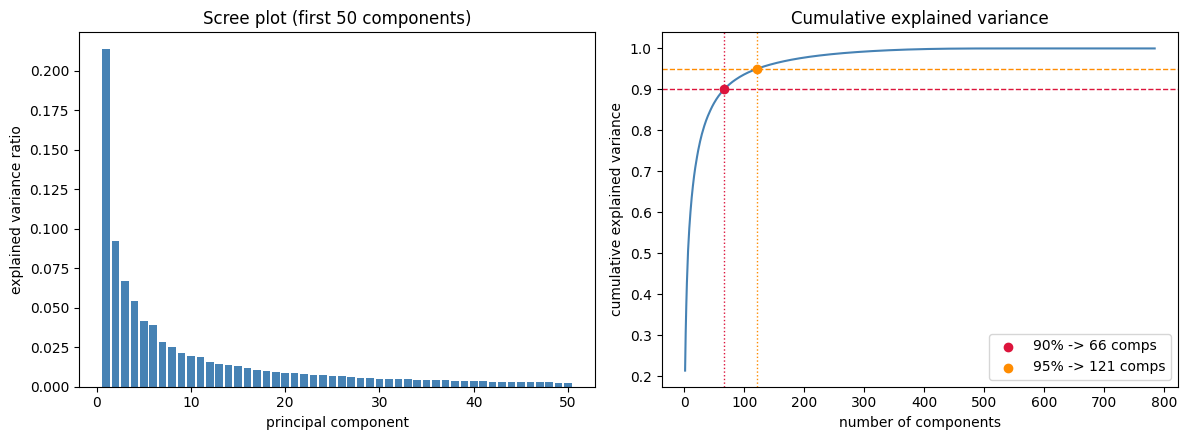

In [6]:
k90 = n_components_for_variance(X, 0.90)
k95 = n_components_for_variance(X, 0.95)
print(f"components for 90% variance: {k90}")
print(f"components for 95% variance: {k95}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

n_show = 50  # the tail is essentially flat
ax1.bar(range(1, n_show + 1), pca.explained_variance_ratio_[:n_show], color="steelblue")
ax1.set_title("Scree plot (first 50 components)")
ax1.set_xlabel("principal component")
ax1.set_ylabel("explained variance ratio")

ax2.plot(range(1, len(cum) + 1), cum, color="steelblue")
for thr, k, c in [(0.90, k90, "crimson"), (0.95, k95, "darkorange")]:
    ax2.axhline(thr, color=c, ls="--", lw=1)
    ax2.axvline(k, color=c, ls=":", lw=1)
    ax2.scatter([k], [thr], color=c, zorder=5, label=f"{thr:.0%} -> {k} comps")
ax2.set_title("Cumulative explained variance")
ax2.set_xlabel("number of components")
ax2.set_ylabel("cumulative explained variance")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

So roughly **66 components** (out of 784) already capture 90% of the variance, and **~121** capture 95% — an ~8-12x reduction in dimensionality with little information lost. The first few components dominate, which is exactly what makes the digits separable in a low-dimensional view below.

## Visualize the first 2 principal components

Projecting each image onto PC1 and PC2 collapses 784 pixels to 2 coordinates. We color each point by its true digit to see how well PCA — which never sees the labels — separates the classes.

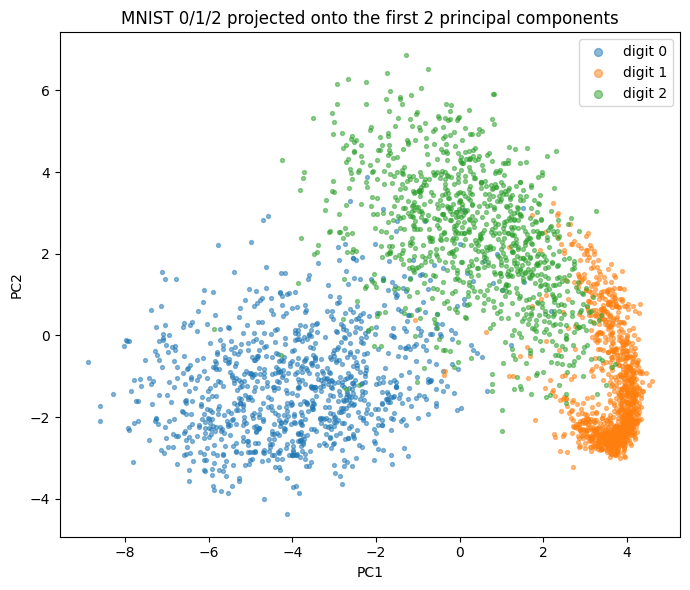

In [7]:
coords = project(pca, X)  # all components; we slice off the leading ones

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["tab:blue", "tab:orange", "tab:green"]
for d, c in zip(DIGITS, colors):
    mask = y == d
    ax.scatter(coords[mask, 0], coords[mask, 1], s=8, alpha=0.5, color=c, label=f"digit {d}")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("MNIST 0/1/2 projected onto the first 2 principal components")
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

## A 3-component view

Adding PC3 gives a little more room to separate the classes that overlap in 2D.

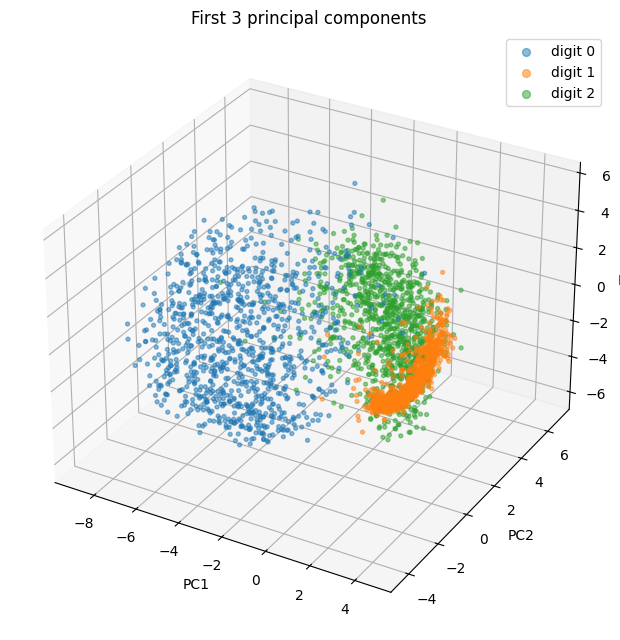

In [8]:
fig = plt.figure(figsize=(8, 6.5))
ax = fig.add_subplot(111, projection="3d")
for d, c in zip(DIGITS, colors):
    mask = y == d
    ax.scatter(coords[mask, 0], coords[mask, 1], coords[mask, 2], s=8, alpha=0.5, color=c, label=f"digit {d}")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("First 3 principal components")
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

## What PCA reveals about the three classes

- **Strong compressibility.** ~66 of 784 components reach 90% variance (~121 for 95%). The pixel space is heavily redundant — neighbouring pixels are correlated and the ink occupies a small, structured region — so PCA compresses it aggressively.
- **Unsupervised class structure.** Even in just 2 dimensions the digits form visibly distinct clouds *without ever using the labels*. **`1`** separates most cleanly (thin, near-vertical strokes give it an extreme, low-variance shape), while **`0`** and **`2`** overlap more because both fill a broad, rounded region of the canvas.
- **PC1/PC2 meaning.** The leading components track the dominant strokes-vs-background contrast and overall shape mass; the third component helps peel apart the 0/2 overlap.

This low-dimensional structure is what the sibling notebooks build on: reconstructing digits from a handful of components (compression) and sampling new ones (generation).